# BERTopic - Vibecoding Tweet Topic Modeling

Notebook ini menjalankan BERTopic pada dataset tweet vibecoding yang sama dengan FASTopic
(`preprocessed_new_vibe_coding_tweets.csv`) supaya hasilnya bisa dibandingkan apple-to-apple.

**Pipeline BERTopic:** sentence embedding (MiniLM) -> UMAP dim reduction -> HDBSCAN clustering ->
c-TF-IDF untuk ekstraksi topic words. Berbeda dengan FASTopic (model probabilistik dengan
transport-plan loss), BERTopic adalah pipeline diskrit berbasis clustering.

In [18]:
import pandas as pd
import numpy as np
import random
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Dataset SAMA persis dengan FASTopic notebook -> hasil dapat dibandingkan langsung.
df_preprocessed = pd.read_csv(r"../preprocessed_new_vibe_coding_tweets.csv")
print(f"Total dokumen: {len(df_preprocessed)}")
df_preprocessed.head()

Total dokumen: 19049


,full_text_translated,image_url
0,vibes capital meets vibecoding greatest econom...,NaN
1,attest vibecoding hella fun borderline like do...,NaN
2,built app ideas spare time one internal tool u...,NaN
3,karpathy discovered secret engineer vibecoding,NaN
4,assisted vibecoding works great data analysis ...,NaN


In [19]:
docs = df_preprocessed['full_text_translated'].fillna('').tolist()
images = df_preprocessed['image_url'].tolist()
for i in range(len(images)):
    if pd.isna(images[i]):
        images[i] = None

# JANGAN shuffle docs supaya index assignment tetap traceable ke dataframe asli.
print(f"Sample doc[0]: {docs[0][:120]}")

Sample doc[0]: vibes capital meets vibecoding greatest economic progress humankind ever seen short term things might look bubbley long 


## Evaluation Setup

Memakai `topmost.Preprocess` HANYA untuk membangun reference corpus + vocabulary yang
identik dengan FASTopic & Top2Vec. Ini penting supaya skor coherence bisa dibandingkan
secara fair antar model (gensim `CoherenceModel` butuh dictionary yang konsisten).

Tiga metric yang dipakai:
- **C_v** — PMI berbasis sliding window + cosine similarity. Range ~0-1. Metric default di literatur BERTopic.
- **C_npmi** — Normalized PMI. Range ~[-1, 1] (~0.05-0.20 untuk tweet). Dipakai di paper FASTopic.
- **Topic diversity** — proporsi kata unik di seluruh top words antar topik. Range 0-1.

In [20]:
from topmost import Preprocess
from topmost.eva import _coherence, _diversity

# Stopwords config IDENTIK dengan FASTopic notebook.
domain_stopwords = ["vibecoding", "vibecode", "vibecoded", "vibe"]
generic_stopwords = [
    "code", "coding", "app", "apps", "build", "building", "built",
    "like", "get", "got", "one", "use", "using", "used", "people",
    "time", "new", "make", "made", "really", "going", "would", "could",
    "even", "much", "still", "also", "thing", "things", "want",
    "way", "ways", "first", "every", "see", "know", "think",
    "good", "great", "right", "now", "today", "yeah", "lot",
]

shared_preprocess = Preprocess(
    vocab_size=5000,
    stopwords=domain_stopwords + generic_stopwords,
    min_doc_count=15,
    max_doc_freq=0.4,
    min_term=5,
)

prep_result = shared_preprocess.preprocess(docs)
ref_corpus = prep_result['train_texts']
ref_vocab = prep_result['vocab']
print(f"Reference corpus: {len(ref_corpus)} docs | vocab: {len(ref_vocab)} terms")

parsing texts: 100%|██████████| 15724/15724 [00:00<00:00, 55277.07it/s]
2026-06-22 15:01:13,914 - TopMost - Real vocab size: 2573
2026-06-22 15:01:13,916 - TopMost - Real training size: 15724 	 avg length: 11.144


Reference corpus: 15724 docs | vocab: 2573 terms


In [21]:
def evaluate_topics(top_words, ref_corpus, ref_vocab, topn=10):
    """Hitung c_v coherence, c_npmi coherence, dan topic diversity.

    top_words: List[str] di mana tiap string = top words satu topik dipisah spasi.
    """
    truncated = [' '.join(tw.split()[:topn]) for tw in top_words]
    cv = _coherence(ref_corpus, ref_vocab, truncated, coherence_type='c_v', topn=topn)
    npmi = _coherence(ref_corpus, ref_vocab, truncated, coherence_type='c_npmi', topn=topn)
    td = _diversity(truncated)
    return {'c_v': cv, 'c_npmi': npmi, 'diversity': td}


def bertopic_top_words(topic_model, topn=15):
    """Ekstrak top words per topic dari BERTopic, exclude outlier topic (-1).
    Output: List[str] dengan format yang sama dengan FASTopic top_words.
    """
    topics = topic_model.get_topics()
    sorted_ids = sorted([tid for tid in topics.keys() if tid != -1])
    return [' '.join([w for w, _ in topics[tid][:topn]]) for tid in sorted_ids]

## BERTopic Config Rationale

- **Embedding model**: `all-MiniLM-L6-v2` -> SAMA dengan FASTopic untuk fairness.
- **`min_topic_size`=50**: Default 10 menghasilkan ratusan micro-topic pada 16k tweets.
  50 lebih sehat untuk corpus segini (mirip threshold yang dipakai paper BERTopic untuk Twitter).
- **`vectorizer_model` shared vocab**: CountVectorizer dipaksa pakai `ref_vocab` yang sama
  dengan FASTopic supaya c-TF-IDF beroperasi di vocabulary yang identik. Ini memastikan
  `evaluate_topics()` jalan dengan dictionary yang konsisten.
- **Pre-compute embeddings sekali**: kita encode semua dokumen sekali lalu reuse untuk tiap K
  di sweep -> hemat ~30 detik per K.

In [22]:
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

EMBED_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

# Pre-compute embeddings SEKALI -> reuse di setiap fit BERTopic untuk hemat waktu.
embed_model = SentenceTransformer(EMBED_MODEL_NAME, device="cuda" if torch.cuda.is_available() else "cpu")
doc_embeddings = embed_model.encode(docs, show_progress_bar=True, batch_size=64)
print(f"Embeddings shape: {doc_embeddings.shape}")

# Vectorizer dengan vocab yang sama dengan FASTopic ref_vocab.
shared_vectorizer = CountVectorizer(vocabulary=ref_vocab)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6211.19it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 298/298 [00:04<00:00, 69.24it/s] 

Embeddings shape: (19049, 384)


## K-Sweep via `nr_topics`

BERTopic awalnya menghasilkan banyak topik dari HDBSCAN, lalu `nr_topics=K` akan otomatis
menggabungkan topik termirip sampai jumlahnya = K. Ini setara dengan K-sweep di FASTopic.

Catatan: BERTopic kadang menghasilkan jumlah topik **lebih kecil** dari target K kalau
HDBSCAN tidak menemukan cukup cluster valid. Karena itu kita track `K_target` (yang diminta)
dan `K_actual` (yang dihasilkan).

In [23]:
from bertopic import BERTopic

K_VALUES = [8, 12, 15, 20, 25]
sweep_results = []

for k in K_VALUES:
    print(f"\n=== Training BERTopic with nr_topics={k} ===")
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    bt = BERTopic(
        embedding_model=embed_model,
        vectorizer_model=shared_vectorizer,
        nr_topics=k,
        min_topic_size=50,
        top_n_words=15,
        calculate_probabilities=False,
        verbose=False,
    )
    bt.fit(docs, embeddings=doc_embeddings)
    tw = bertopic_top_words(bt, topn=10)
    metrics = evaluate_topics(tw, ref_corpus, ref_vocab, topn=10)
    metrics['K_target'] = k
    metrics['K_actual'] = len(tw)
    sweep_results.append(metrics)
    print(f"  target={k} actual={len(tw)}  c_v={metrics['c_v']:.4f}  c_npmi={metrics['c_npmi']:.4f}  diversity={metrics['diversity']:.4f}")
    del bt

sweep_df = pd.DataFrame(sweep_results)[['K_target', 'K_actual', 'c_v', 'c_npmi', 'diversity']]
sweep_df['combined'] = ((sweep_df['c_v'] + (sweep_df['c_npmi'] + 1) / 2) / 2) * sweep_df['diversity']
sweep_df.sort_values('combined', ascending=False)


=== Training BERTopic with nr_topics=8 ===
  target=8 actual=7  c_v=0.4634  c_npmi=0.0064  diversity=0.9429

=== Training BERTopic with nr_topics=12 ===
  target=12 actual=11  c_v=0.4148  c_npmi=-0.0218  diversity=0.9455

=== Training BERTopic with nr_topics=15 ===
  target=15 actual=14  c_v=0.4283  c_npmi=-0.0077  diversity=0.9214

=== Training BERTopic with nr_topics=20 ===
  target=20 actual=19  c_v=0.4255  c_npmi=-0.0206  diversity=0.9158

=== Training BERTopic with nr_topics=25 ===
  target=25 actual=24  c_v=0.3960  c_npmi=-0.0259  diversity=0.9042


,K_target,K_actual,c_v,c_npmi,diversity,combined
0,8,7,0.463395,0.006375,0.942857,0.455675
1,12,11,0.414813,-0.021810,0.945455,0.427302
2,15,14,0.428259,-0.007713,0.921429,0.425886
3,20,19,0.425535,-0.020598,0.915789,0.419082
4,25,24,0.395990,-0.025865,0.904167,0.399215


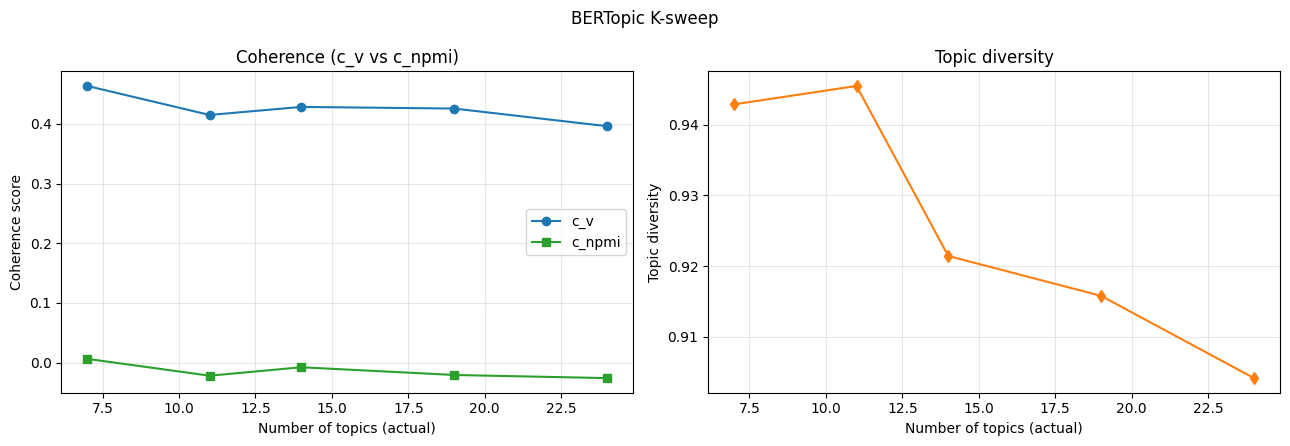


Rekomendasi nr_topics (max combined score): 8
Override manual jika perlu dengan mengubah NUM_TOPICS di cell training di bawah.


In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax1 = axes[0]
ax1.plot(sweep_df['K_actual'], sweep_df['c_v'], 'o-', color='tab:blue', label='c_v')
ax1.plot(sweep_df['K_actual'], sweep_df['c_npmi'], 's-', color='tab:green', label='c_npmi')
ax1.set_xlabel('Number of topics (actual)')
ax1.set_ylabel('Coherence score')
ax1.set_title('Coherence (c_v vs c_npmi)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = axes[1]
ax2.plot(sweep_df['K_actual'], sweep_df['diversity'], 'd-', color='tab:orange')
ax2.set_xlabel('Number of topics (actual)')
ax2.set_ylabel('Topic diversity')
ax2.set_title('Topic diversity')
ax2.grid(alpha=0.3)

plt.suptitle('BERTopic K-sweep')
fig.tight_layout()
plt.show()

best_idx = sweep_df['combined'].idxmax()
best_k = int(sweep_df.loc[best_idx, 'K_target'])
print(f"\nRekomendasi nr_topics (max combined score): {best_k}")
print("Override manual jika perlu dengan mengubah NUM_TOPICS di cell training di bawah.")

## Final Model

In [25]:
NUM_TOPICS = best_k

np.random.seed(SEED)
torch.manual_seed(SEED)

model = BERTopic(
    embedding_model=embed_model,
    vectorizer_model=shared_vectorizer,
    nr_topics=NUM_TOPICS,
    min_topic_size=50,
    top_n_words=15,
    calculate_probabilities=True,
    verbose=True,
)
topics, probs = model.fit_transform(docs, embeddings=doc_embeddings)

top_words = bertopic_top_words(model, topn=15)
final_metrics = evaluate_topics(top_words, ref_corpus, ref_vocab, topn=10)
print(
    f"\nFinal BERTopic | target K={NUM_TOPICS}  actual={len(top_words)}"
    f"  c_v={final_metrics['c_v']:.4f}"
    f"  c_npmi={final_metrics['c_npmi']:.4f}"
    f"  diversity={final_metrics['diversity']:.4f}\n"
)
for i, tw in enumerate(top_words):
    print(f"Topic {i}: {tw}")

bertopic_metrics = {**final_metrics, 'model': 'BERTopic', 'K': len(top_words)}

2026-06-22 15:04:34,614 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-22 15:04:36,783 - BERTopic - Dimensionality - Completed ✓
2026-06-22 15:04:36,784 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-22 15:04:39,097 - BERTopic - Cluster - Completed ✓
2026-06-22 15:04:39,097 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-06-22 15:04:39,295 - BERTopic - Representation - Completed ✓
2026-06-22 15:04:39,296 - BERTopic - Topic reduction - Reducing number of topics
2026-06-22 15:04:39,331 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-22 15:04:39,484 - BERTopic - Representation - Completed ✓
2026-06-22 15:04:39,486 - BERTopic - Topic reduction - Reduced number of topics from 36 to 8



Final BERTopic | target K=8  actual=7  c_v=0.4308  c_npmi=0.0027  diversity=0.9429

Topic 0: game claude agent agents gemini games tools software security real next programming day need fun
Topic 1: cursor windsurf agent claude mode work project mcp file lovable copilot something changes feature composer
Topic 2: troll meme coin solana meta coins ppl trading btc sell memes narrative pump launchpad say
Topic 3: doctors practice healthcare practices private health tech services care docs digital cheap market compliance nothing
Topic 4: gpt codex oss claude models gemini best opus openai forth improvements brings previous mac iterate
Topic 5: cooking cook cooked food gon heard amazing let called lunch eat eating cracked big anywhere
Topic 6: rust typescript workshop series safe hackathon compiler python weekend language rsvp memory type tried kicking


In [26]:
# Topic info table dari built-in BERTopic
topic_info = model.get_topic_info()
topic_info.head(50)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,11125,-1_day_tools_work_need,"[day, tools, work, need, software, something, ...",[new vibecoding trend changing developers buil...
1,0,7171,0_game_claude_agent_agents,"[game, claude, agent, agents, gemini, games, t...",[people vibecoding video games using opportuni...
2,1,381,1_cursor_windsurf_agent_claude,"[cursor, windsurf, agent, claude, mode, work, ...",[cursor take wheel cursor always handles publi...
3,2,96,2_troll_meme_coin_solana,"[troll, meme, coin, solana, meta, coins, ppl, ...","[trollollo troll strength undeniable, outperfo..."
4,3,79,3_doctors_practice_healthcare_practices,"[doctors, practice, healthcare, practices, pri...",[templates made software practice compliance e...
5,4,67,4_gpt_codex_oss_claude,"[gpt, codex, oss, claude, models, gemini, best...",[gpt best coding tested gpt claude gemini usin...
6,5,66,5_cooking_cook_cooked_food,"[cooking, cook, cooked, food, gon, heard, amaz...","[let goooooo cooking vibecoding happy see, vib..."
7,6,64,6_rust_typescript_workshop_series,"[rust, typescript, workshop, series, safe, hac...",[next weekend building rust workshop series co...


In [27]:
# Intertopic distance map
fig = model.visualize_topics()
fig.show()

In [28]:
# Top words per topic dengan c-TF-IDF weights
fig = model.visualize_barchart(top_n_topics=min(NUM_TOPICS, 12), n_words=8)
fig.show()

In [29]:
# Hierarchical view
fig = model.visualize_hierarchy()
fig.show()

In [30]:
# Sample tweets per topic untuk inspeksi kualitatif
def sample_docs_for_topic(topic_id, n=3):
    idx = [i for i, t in enumerate(topics) if t == topic_id]
    if not idx:
        return []
    pick = np.random.choice(idx, size=min(n, len(idx)), replace=False)
    return [docs[i] for i in pick]

# Skip outlier topic -1, ambil top 10 berdasarkan size
non_outlier = topic_info[topic_info['Topic'] != -1].head(10)
for _, row in non_outlier.iterrows():
    tid = row['Topic']
    print(f"\n=== Topic {tid} | size={row['Count']} | {row['Name'][:80]} ===")
    for s in sample_docs_for_topic(tid, n=3):
        print(" -", s[:200])


=== Topic 0 | size=7171 | 0_game_claude_agent_agents ===
 - communists vibecode objects start talking unions
 - moa mixture agents better results
 - vibecoding prompt kit gives scaffolding mindset scaffold aware prompts plus one prompt template turns fuzzy ideas blueprints

=== Topic 1 | size=381 | 1_cursor_windsurf_agent_claude ===
 - confused cheetah used cheetah assistant vibecoding essentially turning anyone developer cheetah biggest competitor cursor read cheetah different
 - cursor meteoric rise vibecoding fueled arr startup without dollar marketing
 - caught attention coding vibecoding look vibecoding disaster code bros cursor experts complete guide cursor non coders vibecoding

=== Topic 2 | size=96 | 2_troll_meme_coin_solana ===
 - vibecoding new launching meme coin
 - good day troll keep mind meme tier cex listings yet one binancable coinbaseable narrative par pepe
 - mny soon zera test see vision targets least mcap

=== Topic 3 | size=79 | 3_doctors_practice_healthcare_prac

In [31]:
import os

os.makedirs("artifacts", exist_ok=True)
model.save("artifacts/bertopic_vibecoding", serialization="safetensors", save_ctfidf=True)

assignments = pd.DataFrame({
    "doc": docs,
    "topic_id": topics,
    "topic_prob": probs.max(axis=1) if probs is not None else np.nan,
})
assignments.to_csv("artifacts/bertopic_assignments.csv", index=False)
topic_info.to_csv("artifacts/bertopic_topic_info.csv", index=False)
sweep_df.to_csv("artifacts/bertopic_sweep.csv", index=False)
print("Saved BERTopic artifacts.")

Saved BERTopic artifacts.


## Topic over Time

Memvisualisasikan evolusi topik sepanjang waktu memakai kolom `created_at` dari dataset
sumber (`vibe_coding_combined_translated.csv`). File preprocessed tidak menyimpan timestamp,
jadi `created_at` direkonstruksi dengan menjalankan ulang pipeline preprocessing yang **identik**
dengan `preprocess_new.ipynb` (decode HTML -> lowercase -> hapus URL/mention/hashtag ->
normalisasi "vibe coding" -> tokenize -> buang stopword + token <=2 char -> filter dokumen
>= 4 token). Karena pipeline ini deterministik & mempertahankan urutan baris, hasilnya selaras
per-posisi dengan `docs` (BERTopic TIDAK men-shuffle docs, sehingga mapping langsung 1:1).

In [32]:
import re, html
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Pastikan resource nltk tersedia (sama dengan preprocess_new.ipynb).
for _res, _path in [("stopwords", "corpora/stopwords"),
                    ("punkt", "tokenizers/punkt"),
                    ("punkt_tab", "tokenizers/punkt_tab")]:
    try:
        nltk.data.find(_path)
    except LookupError:
        nltk.download(_res)

_stop_words = set(stopwords.words("english"))


def _preprocess_tweet_v2(text):
    """Replika persis preprocess_tweet_v2 di preprocess_new.ipynb."""
    text = html.unescape(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"vibe\s+coding", "vibecoding", text)
    text = re.sub(r"vibe\s+code", "vibecode", text)
    text = re.sub(r"vibe\s+coded", "vibecoded", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\d+", "", text)
    tokens = word_tokenize(text)
    return " ".join([w for w in tokens if w not in _stop_words and len(w) > 2])


# Rekonstruksi created_at selaras dengan urutan baris file preprocessed.
SOURCE_CSV = r"../../combined_tweets_dataset/sample_v2/vibe_coding_combined_translated.csv"
_src = pd.read_csv(SOURCE_CSV)
_cleaned = _src["full_text_translated"].fillna("").apply(_preprocess_tweet_v2)
_mask = _cleaned.apply(lambda x: len(x.split()) >= 4)

doc_order_text = _cleaned[_mask].reset_index(drop=True)
doc_order_time = pd.to_datetime(_src.loc[_mask, "created_at"].reset_index(drop=True), utc=True)

# docs BERTopic TIDAK di-shuffle -> selaras langsung per posisi. Assert menjaga alignment.
assert len(doc_order_text) == len(docs), f"recovered {len(doc_order_text)} != docs {len(docs)}"
assert (doc_order_text.values == pd.Series(docs).values).all(), \
    "Alignment mismatch — pastikan cell `docs` dijalankan dari file preprocessed yang sama."

timestamps = doc_order_time.tolist()
print(f"Aligned {len(timestamps)} timestamps | {doc_order_time.min()} -> {doc_order_time.max()}")

Aligned 19049 timestamps | 2025-02-02 23:35:08+00:00 -> 2026-02-27 23:59:31+00:00


In [33]:
# Hitung representasi topik per bin waktu. Data span ~13 bulan -> nr_bins=13 (~bulanan).
# BERTopic me-recompute c-TF-IDF per bin memakai topik global yang sudah di-fit.
topics_over_time = model.topics_over_time(docs, timestamps, nr_bins=13)
topics_over_time.head()

13it [00:00, 36.82it/s]


,Topic,Words,Frequency,Timestamp
0,-1,"tools, work, need, next, day",835,2025-02-02 14:13:30.537000+00:00
1,0,"claude, agent, game, programming, software",476,2025-02-02 14:13:30.537000+00:00
2,1,"cursor, agent, windsurf, composer, project",103,2025-02-02 14:13:30.537000+00:00
3,2,"solana, meme, coins, coin, troll",11,2025-02-02 14:13:30.537000+00:00
4,3,"practice, doctors, practices, private, healthcare",17,2025-02-02 14:13:30.537000+00:00


In [34]:
# Visualisasi frekuensi topik sepanjang waktu (outlier -1 otomatis di-exclude).
fig = model.visualize_topics_over_time(topics_over_time, top_n_topics=min(NUM_TOPICS, 10))

# Pindahkan legend ke bawah graph (horizontal) supaya area plot lebih lebar.
fig.update_layout(
    legend=dict(
        orientation="h",      # legend mendatar
        yanchor="top",
        y=-0.20,              # di bawah area plot (negatif = di luar bawah)
        xanchor="center",
        x=0.5,
        title_text="",
    ),
    margin=dict(b=160),       # ruang ekstra di bawah untuk menampung legend
)
fig.show()